#Audio filter project

In [43]:
import numpy as np
from scipy.fft import rfft, rfftfreq, irfft
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import librosa
import soundfile as sf

Loadding the ".WAV" file.


In [10]:
y, sr = librosa.load(
    'Dr Martin Luther King Jr on MTP days before famous.wav',
    sr=None)

In [17]:
t = np.arange(len(y)) / sr

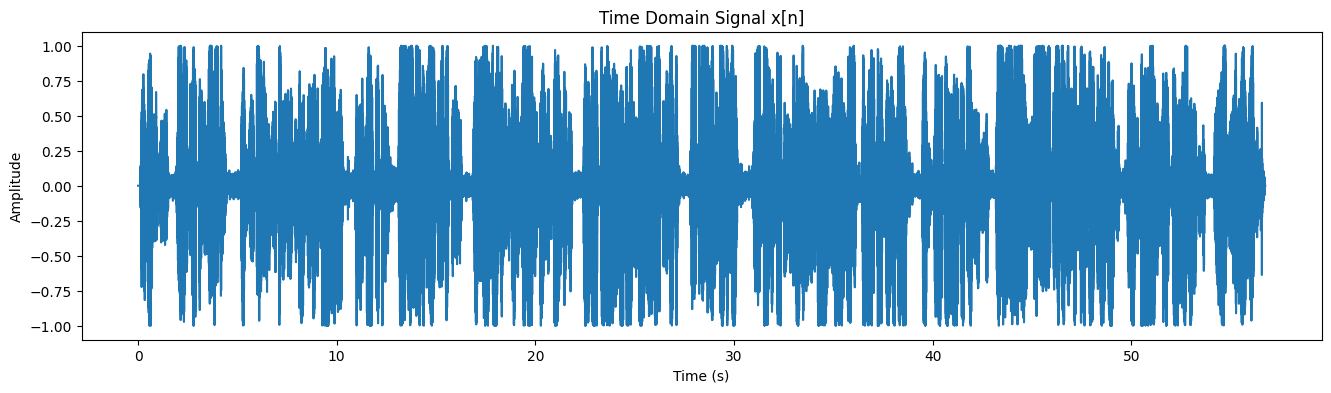

In [20]:
plt.figure(figsize=(16, 4))
plt.plot(t, y)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Time Domain Signal x[n]")
plt.show()

Observation:

Peaks → loud parts (speech)

Flat/low → silence or background noise

Irregular patterns → natural speech


In [21]:
print("sampling rate: ", sr)


sampling rate:  44100


the sampling rate show that what is the signals {which is a digital signal} is sample of 44k data persecond or 44khz frequency:



#Frequency Domain (Fourier Transform)

Changing the time domain signal to a frequecy domain signal. But why?

Speech-analysis is hard in time domain → easier in frequency domain. since we are using simple python modules for analysis.
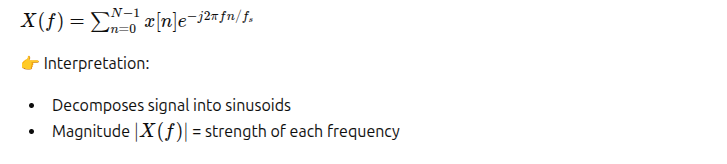

Docs

SciPy FFT:https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.rfft.html

Frequency bins:https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.rfftfreq.html

FFT :https://numpy.org/doc/stable/reference/routines.fft.html

In [24]:
Y = rfft(y)
freqs = rfftfreq(len(y), 1/sr)

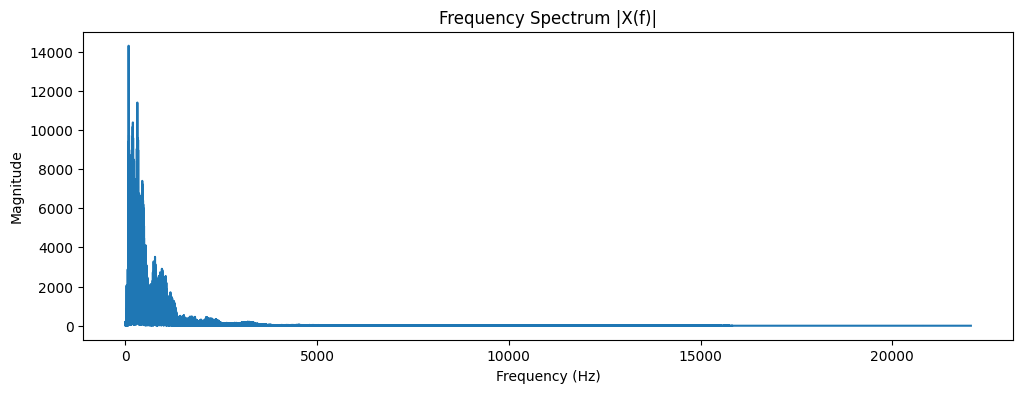

In [31]:
plt.figure(figsize=(12,4))
plt.plot(freqs, np.abs(Y))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum |X(f)|")
plt.show()

Observations:

```
Peaks between 300–3400 Hz → speech
Low frequencies → rumble/noise
High frequencies → hiss
```
so, since our graph indicate that the signal is having picks at low frequency this show that the signal has noise/rumble.

#Identifing Speech Vs Noise

Observation:

the human speech is most probable laid in the range of 300-3400Hz frequency otherways it is noise or hiss.

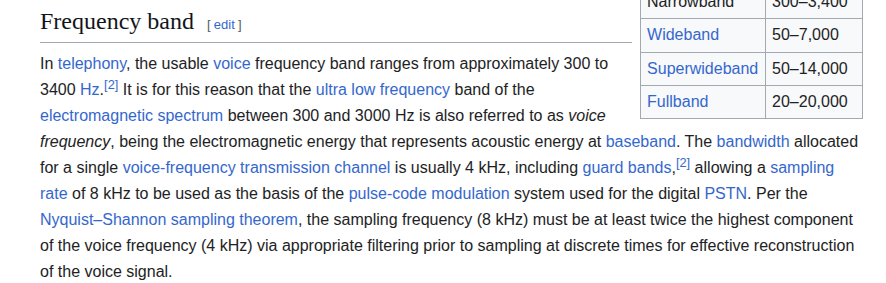


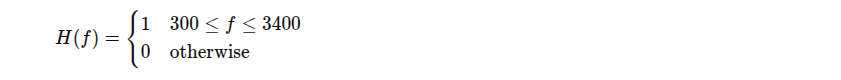

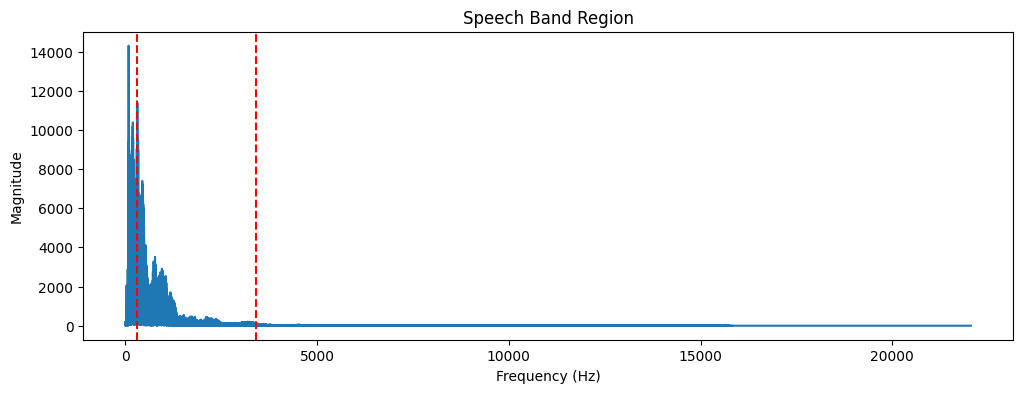

In [30]:
plt.figure(figsize=(12,4))
plt.plot(freqs, np.abs(Y))
plt.axvline(300, color='r', linestyle='--')
plt.axvline(3400, color='r', linestyle='--')
plt.title("Speech Band Region")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

# Apply the Filter

#### Using Two Methods
1. FFT Mask

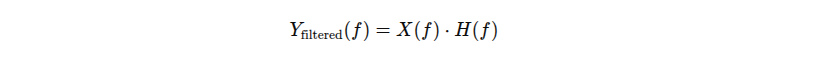


**𝑋(𝑓): original signal**

**𝐻(𝑓): band-pass filter**

In [39]:
low = 300
high = 3400

mask = (freqs >= low) & (freqs <= high)
Y_filtered = Y * mask

In [41]:
y_clean_first_resut = irfft(Y_filtered)

#### 2. Method-2

In [45]:
def bandpass(x, low, high, sr, order=4):
    nyq = 0.5 * sr
    low /= nyq
    high /= nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, x)

y_clean_second_result = bandpass(y, 300, 3400, sr)